# Домашнее задание 3
## Визуализация данных Titanic

## Загрузка датасета

Считаем датасет Titanic из файла `train.csv` и посмотрим на первые строки таблицы.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Распределение признаков

Построим графики распределения следующих переменных:

- Survived
- Pclass
- Age
- Sex
- Parch

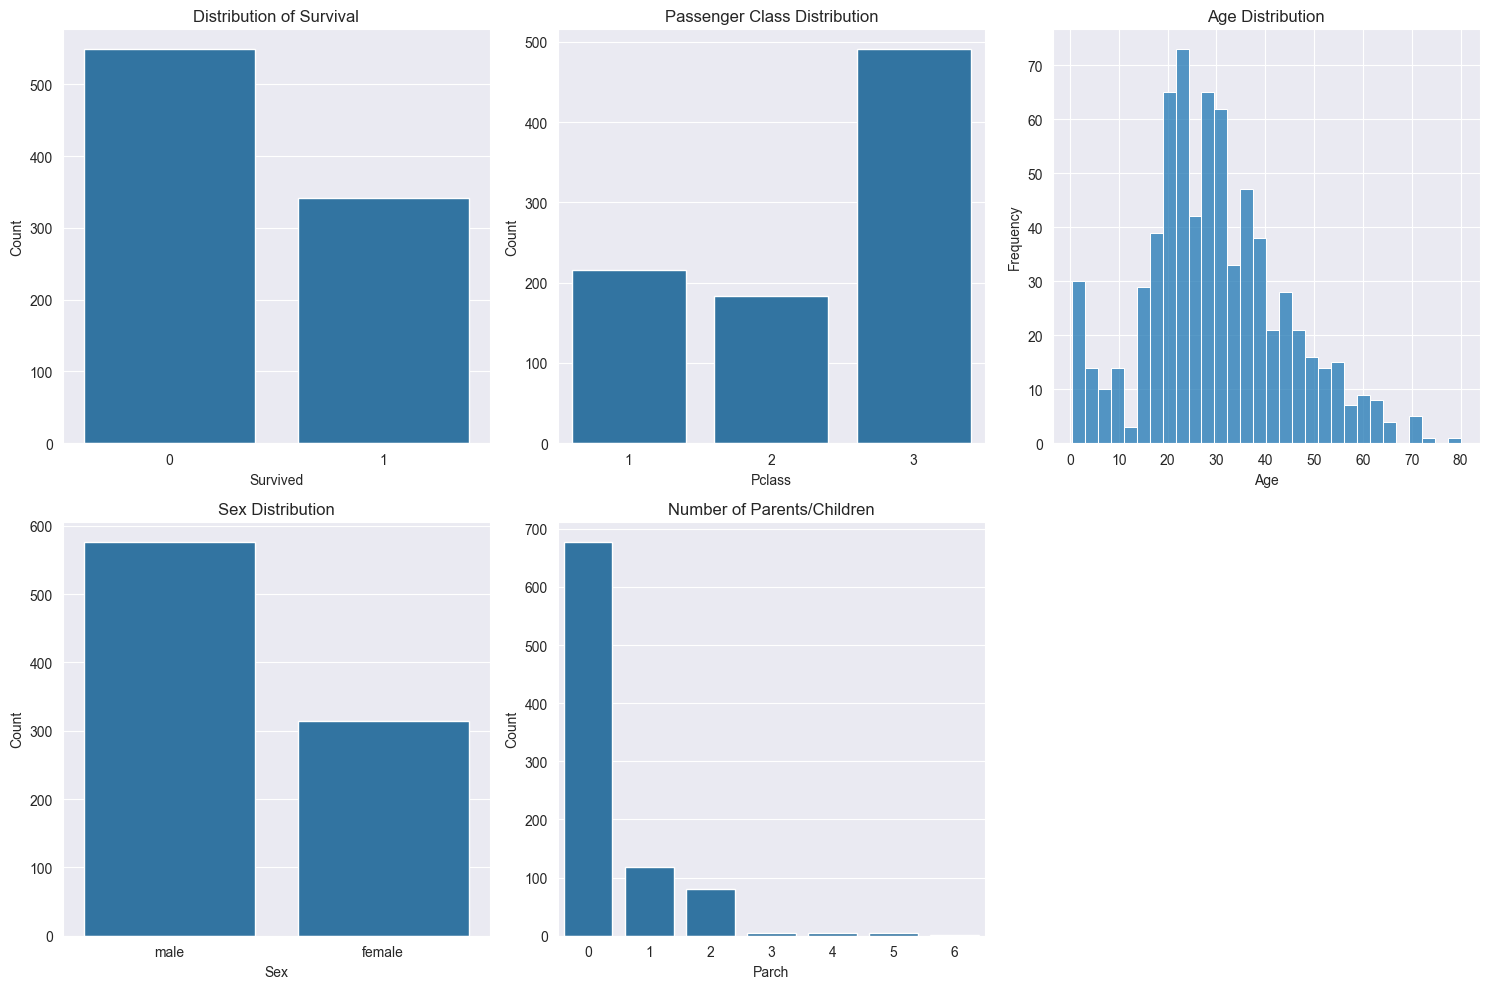

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

sns.countplot(x="Survived", data=df, ax=axes[0,0])
axes[0,0].set_title("Distribution of Survival")
axes[0,0].set_xlabel("Survived")
axes[0,0].set_ylabel("Count")

sns.countplot(x="Pclass", data=df, ax=axes[0,1])
axes[0,1].set_title("Passenger Class Distribution")
axes[0,1].set_xlabel("Pclass")
axes[0,1].set_ylabel("Count")

sns.histplot(df["Age"].dropna(), bins=30, ax=axes[0,2])
axes[0,2].set_title("Age Distribution")
axes[0,2].set_xlabel("Age")
axes[0,2].set_ylabel("Frequency")

sns.countplot(x="Sex", data=df, ax=axes[1,0])
axes[1,0].set_title("Sex Distribution")
axes[1,0].set_xlabel("Sex")
axes[1,0].set_ylabel("Count")

sns.countplot(x="Parch", data=df, ax=axes[1,1])
axes[1,1].set_title("Number of Parents/Children")
axes[1,1].set_xlabel("Parch")
axes[1,1].set_ylabel("Count")

axes[1,2].axis("off")

plt.tight_layout()
plt.show()

## Boxplot для возраста

Boxplot показывает распределение возраста пассажиров, включая медиану, квартильные интервалы и возможные выбросы.

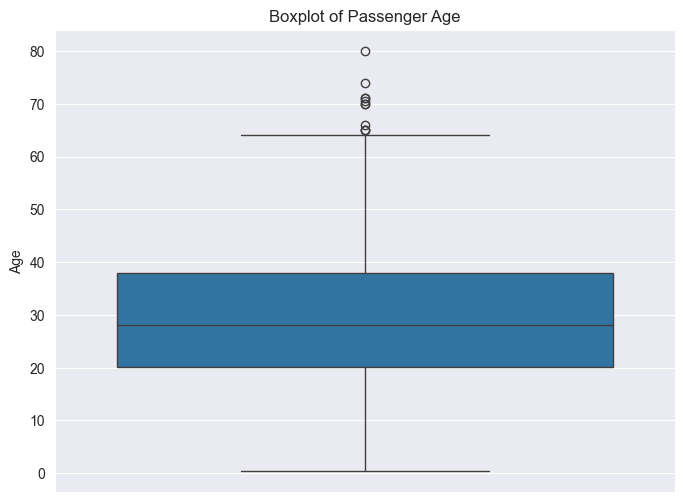

In [3]:
plt.figure(figsize=(8,6))

sns.boxplot(y=df["Age"])

plt.title("Boxplot of Passenger Age")
plt.ylabel("Age")

plt.show()

Boxplot показывает распределение возраста пассажиров.

Медиана находится примерно в районе 28–30 лет.
Большинство пассажиров находится в диапазоне примерно от 20 до 40 лет.

Также можно наблюдать выбросы — пассажиров старшего возраста (60–80 лет), которые встречаются значительно реже.

## Pie chart для Survived и Pclass

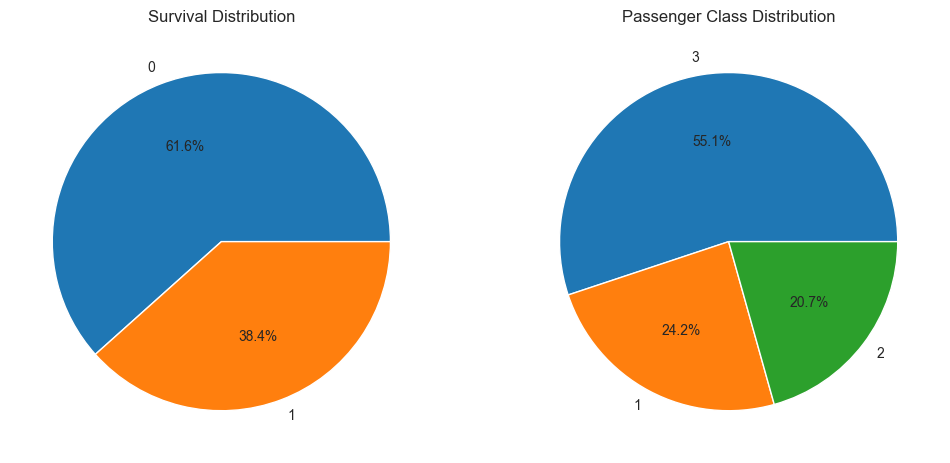

In [4]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

df["Survived"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[0]
)

axes[0].set_title("Survival Distribution")
axes[0].set_ylabel("")

df["Pclass"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1]
)

axes[1].set_title("Passenger Class Distribution")
axes[1].set_ylabel("")

plt.show()

## Pairplot числовых переменных

Pairplot позволяет увидеть взаимосвязи между числовыми признаками датасета.

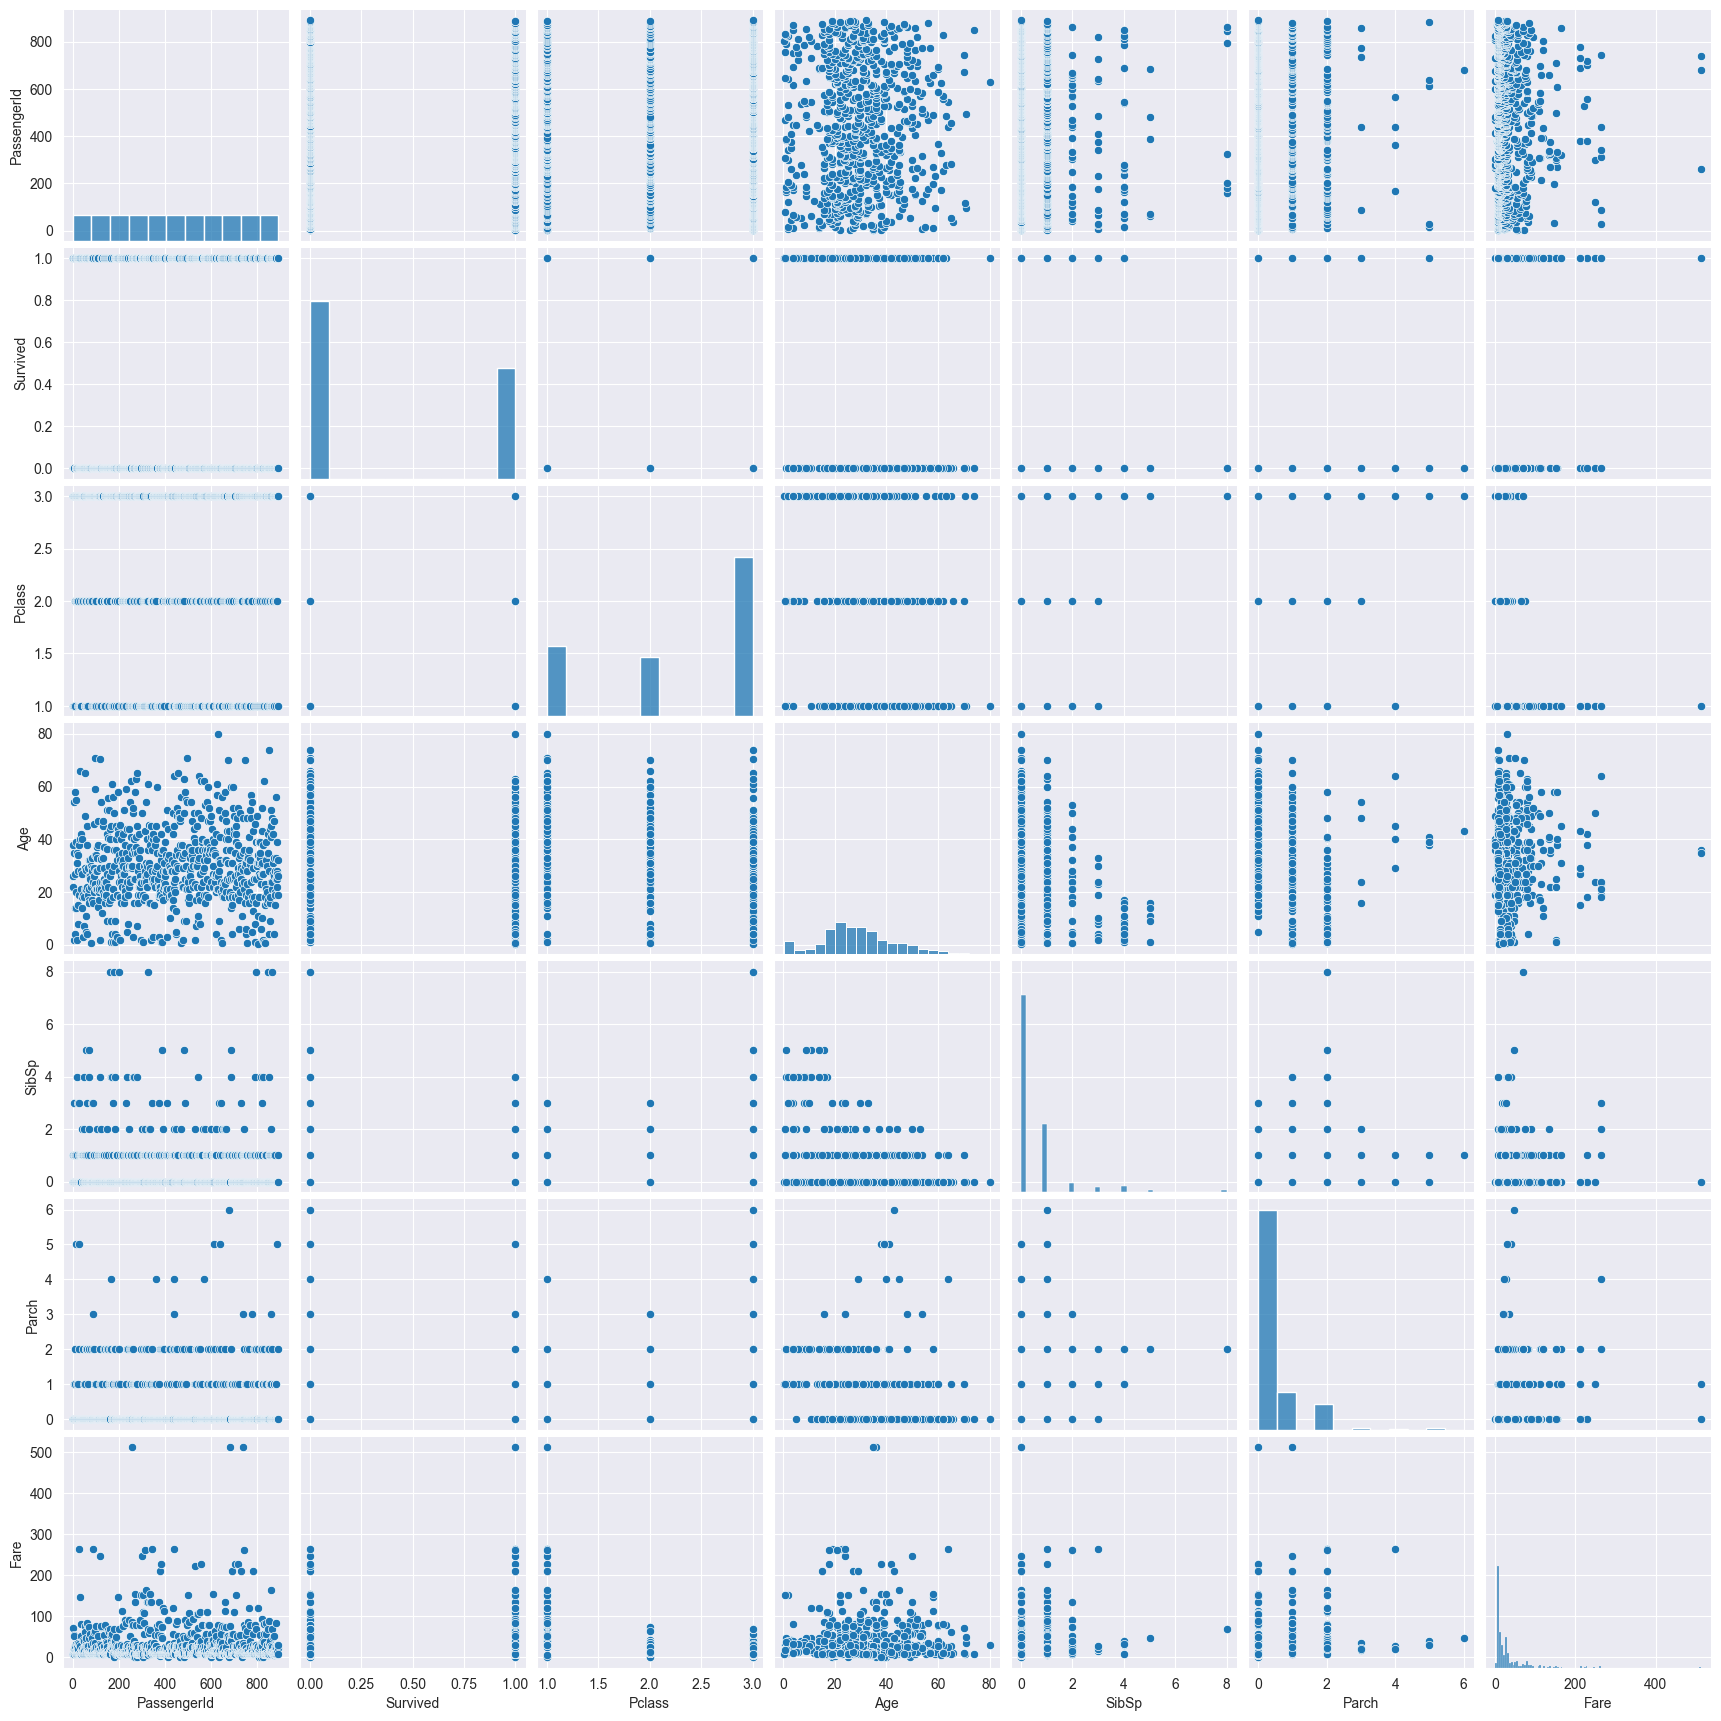

In [5]:
numeric_df = df.select_dtypes(include=["int64","float64"])

sns.pairplot(numeric_df)

plt.show()

## Violin plot возраста в зависимости от пола

График показывает распределение возраста мужчин и женщин.

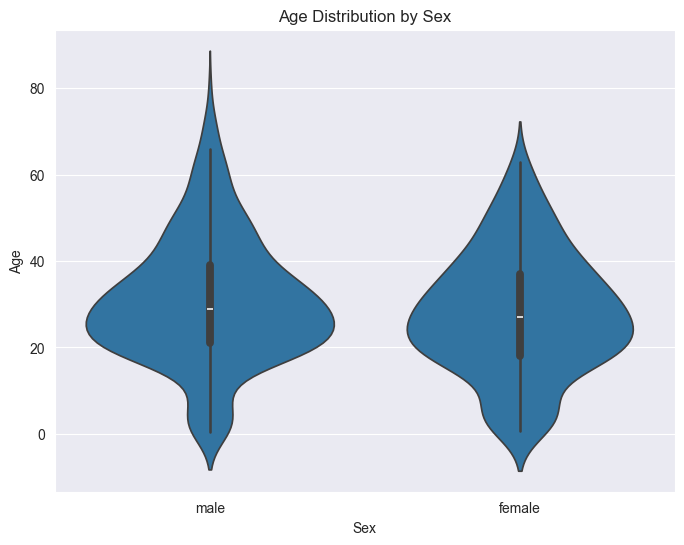

In [6]:
plt.figure(figsize=(8,6))

sns.violinplot(x="Sex", y="Age", data=df)

plt.title("Age Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Age")

plt.show()

## Корреляционная матрица

Построим тепловую карту корреляций между числовыми признаками.

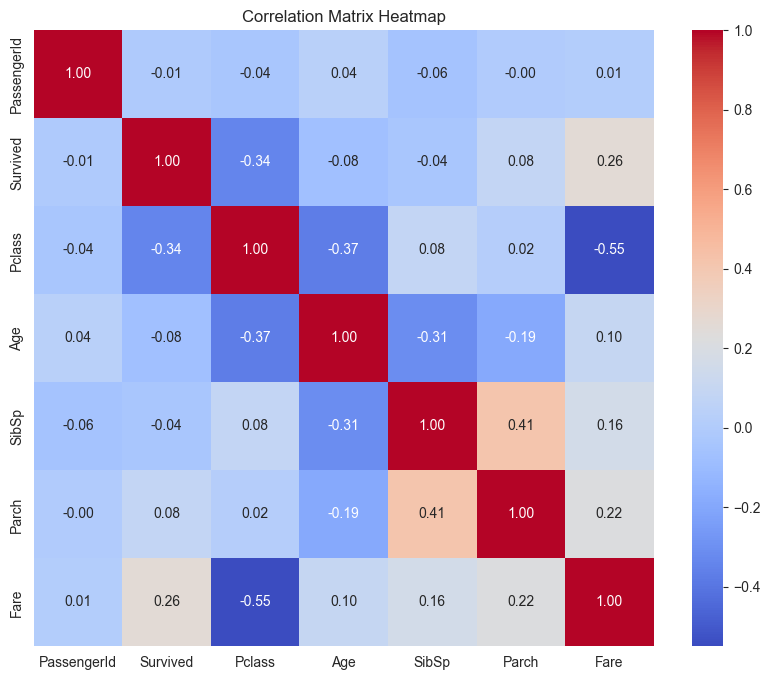

In [7]:
plt.figure(figsize=(10,8))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")

plt.show()

## Sunburst plot

График показывает:

- первый уровень — количество пассажиров по классам
- второй уровень — распределение мужчин и женщин внутри каждого класса

In [8]:
fig = px.sunburst(
    df,
    path=["Pclass","Sex"],
    title="Passenger Distribution by Class and Sex"
)

fig.show()

## Вывод

В ходе анализа были построены различные визуализации данных Titanic.

Основные наблюдения:

- распределение пассажиров по классам и полу показывает значительные различия;
- большинство пассажиров находилось в возрасте от 20 до 40 лет;
- корреляционная матрица позволяет выявить связи между признаками;
- интерактивный sunburst-график показывает структуру пассажиров по классу и полу.

Использование различных типов графиков помогает лучше понять структуру данных и выявить закономерности.